In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
from arte.math.toccd import toccd

In [2]:
def reshape_on_mask(a,mask):
    img_2d = np.zeros(mask.shape)
    img_2d[~mask] = a.copy()
    img_2d = img_2d.reshape(mask.shape)
    return img_2d

def image_grid(shape, recenter:bool = False):
    ny, nx = shape
    cy, cx = (0,0)
    if recenter:
        cy, cx = ny//2, nx//2
    x = np.arange(nx, dtype=float) - cx
    y = np.arange(ny, dtype=float) - cy
    X,Y = np.meshgrid(x, y)
    return X,Y

def get_photocenter(image,offset:bool=False):
    X,Y = image_grid(image.shape)
    qy = np.sum(Y * image) / np.sum(image)
    qx = np.sum(X * image) / np.sum(image)
    if offset:
        qy += 0.5
        qx += 0.5
    return qx,qy 

def rebin(a, shape):
    # sh = shape[0],a.shape[0]//shape[0],shape[1],a.shape[1]//shape[1]
    # return np.nanmean(np.nanmean(a.reshape(sh),axis=-1),axis=1)
    # return a.reshape(sh).mean(-1).mean(1)
    if isinstance(a,np.ma.masked_array):
        a_mask = a.mask
        a = a.data
    a_mask = np.isnan(a)
    a = reshape_on_mask(a[~a_mask],a_mask)
    b = toccd(a,shape)
    return b*np.std(a)/np.std(b)

def remove_ifs(img,IF,mask,return_fit_pars:bool=False):
    R = np.linalg.pinv(IF)
    if_coeffs = R @ img[~mask]
    rec_img = reshape_on_mask(IF @ if_coeffs,mask)
    img = img - rec_img
    if return_fit_pars is False:
        return img
    else:
        return img, rec_img, if_coeffs

In [3]:
if_path = '/mnt/libero/SPLATTData/Data/OPTData/IFFunctions'
im_path = '/mnt/libero/SPLATTData/Data/OPTData/IntMatrices'
raw_img_path = '/mnt/libero/SPLATTData/Data/OPTData/OPDImages'
tn = '20250819_164905'

hdu = fits.open(os.path.join(im_path,tn,'IMCube.fits'))
IMcube = hdu[0].data
masks = hdu[1].data

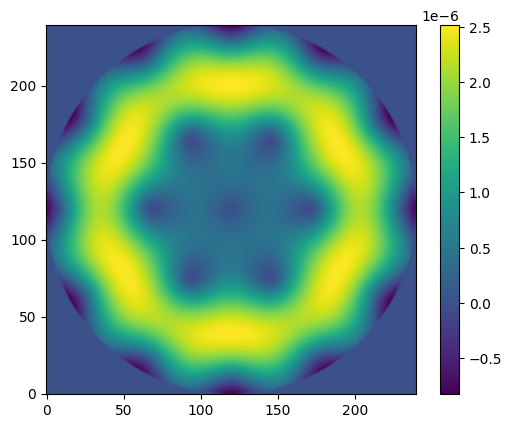

In [4]:
grav = np.loadtxt('../../SPLATT_Data/splatt_grav_def.txt')

grav_rebin = rebin(grav,(240,240))

plt.figure()
plt.imshow(grav_rebin)
plt.colorbar()

In [5]:
# mask_shape = (IMcube.shape[0],IMcube.shape[1])
# master_mask = np.zeros(mask_shape,dtype=bool)
# for k in range(IMcube.shape[-1]):
#     master_mask = np.logical_or(master_mask,masks[:,:,k])

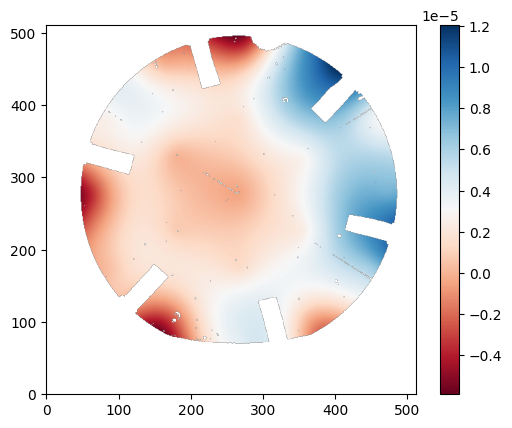

In [6]:
Nacts = 19
N = 3*Nacts

# Define master mask
mask_shape = (IMcube.shape[0],IMcube.shape[1]) #(128,128)
master_mask = np.zeros(mask_shape,dtype=bool)
for k in range(N):
    hdu = fits.open(os.path.join(raw_img_path,tn,f'image_{k:05}.fits'))
    mask = hdu[1].data.copy()
    mask_rebin = rebin(mask,mask_shape)
    master_mask = np.logical_or(master_mask,mask_rebin)

avg_img = np.zeros(np.sum(1-master_mask))
# Define average image
for k in range(N):
    hdu = fits.open(os.path.join(raw_img_path,tn,f'image_{k:05}.fits'))
    img = hdu[0].data.copy()
    img_rebin = rebin(img,mask_shape)
    avg_img += img_rebin[~master_mask]/N

# avg_img = np.nanmean(img_rebin,axis=0)
avg_img_2d = reshape_on_mask(avg_img, master_mask)

plt.figure()
plt.imshow(np.ma.masked_array(avg_img_2d,mask=master_mask),origin='lower',cmap='RdBu')
plt.colorbar()

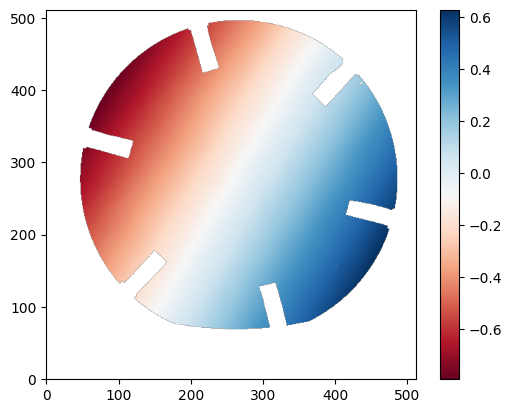

In [7]:
plt.figure()
plt.imshow(np.ma.masked_array(IMcube[:,:,1],mask=masks[:,:,1]),origin='lower',cmap='RdBu')
plt.colorbar()

In [8]:
IF = np.zeros([np.sum(1-master_mask),Nacts],dtype=float)
for j in range(Nacts):
    im = rebin(IMcube[:,:,j],mask_shape)
    IF[:,j] = im[~master_mask]

IF_full = IF.copy()

In [9]:
U,D,Vt = np.linalg.svd(IF,full_matrices=False)
R = (Vt.T * 1/D) @ U.T

Text(0.5, 1.0, 'Residual shape\nRMS=588.2nm')

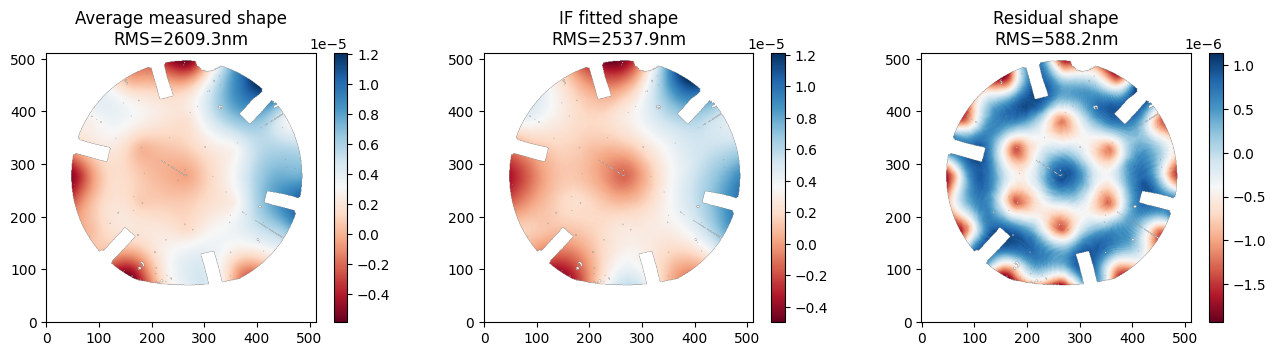

In [10]:
coeffs = R @ avg_img
fit_img = IF @ coeffs

fit_img_2d = reshape_on_mask(fit_img,master_mask)
diff = avg_img_2d-fit_img_2d
diff -= np.mean(diff)

plt.figure(figsize=(16,3.5))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(avg_img_2d,mask=master_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'Average measured shape\nRMS={np.std(avg_img_2d[~master_mask])*1e+9:1.1f}nm')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(fit_img_2d,mask=master_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'IF fitted shape\nRMS={np.std(fit_img_2d[~master_mask])*1e+9:1.1f}nm')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(diff,mask=master_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'Residual shape\nRMS={np.std(diff[~master_mask])*1e+9:1.1f}nm')

In [11]:
from scipy.interpolate import Rbf

pad = 32
pad_diff = np.pad(diff,pad_width=((0,pad),(0,pad)),mode='constant',constant_values=0.0)
pad_avg_img_2d = np.pad(avg_img_2d,pad_width=((0,pad),(0,pad)),mode='constant',constant_values=0.0)
pad_master_mask = np.pad(master_mask,pad_width=((0,pad),(0,pad)),mode='constant',constant_values=True)

# Extrapolate missing data in image using thin-plate-spline interpolation
binned_shape = (140,140)
img_rebin = rebin(pad_diff,binned_shape)
mask_rebin = np.array(rebin(pad_master_mask,binned_shape),dtype=bool)

# Extract valid (non-masked) pixel coordinates and values
valid_mask = ~mask_rebin
y_valid, x_valid = np.where(valid_mask)
z_valid = img_rebin[valid_mask]

# Create RBF interpolator with thin-plate spline
rbf = Rbf(x_valid, y_valid, z_valid, function='thin_plate', smooth=0)

# Evaluate RBF on full grid to fill holes
Y, X = np.mgrid[0:img_rebin.shape[0], 0:img_rebin.shape[1]]
diff_fill = rbf(X, Y)


Text(0.5, 1.0, 'Difference')

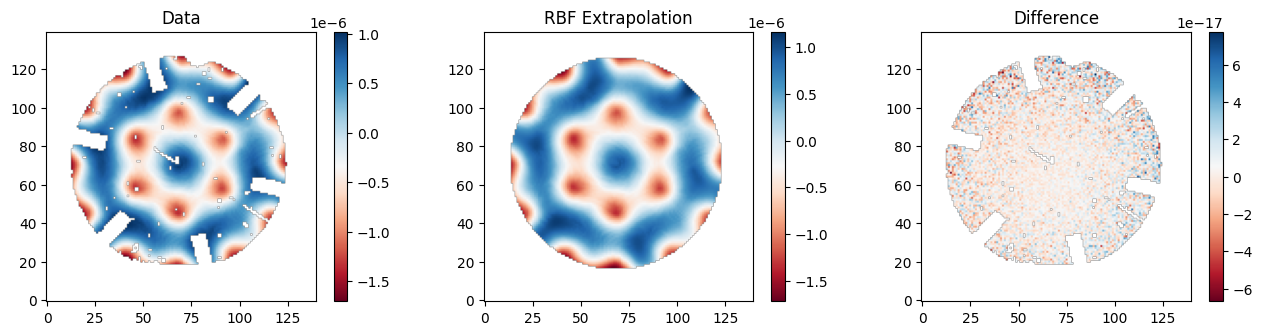

In [12]:
rho = lambda x,y, xc, yc: np.sqrt((x-xc)**2+(y-yc)**2)
mask_fill = np.fromfunction(lambda i,j: rho(i,j,71,68)>=440/4/2, img_rebin.shape).astype(bool)
mask_inner = np.fromfunction(lambda i,j: rho(i,j,71,68)>=350/4/2, img_rebin.shape).astype(bool)

# Optionally show the filled image
plt.figure(figsize=(16, 3.5))
plt.subplot(1, 3, 1)
plt.imshow(np.ma.masked_array(img_rebin, mask=mask_rebin), origin='lower', cmap='RdBu')
plt.colorbar()
plt.title('Data')
plt.subplot(1, 3, 2)
plt.imshow(np.ma.masked_array(diff_fill, mask=mask_fill), origin='lower', cmap='RdBu')
plt.colorbar()
plt.title('RBF Extrapolation')
plt.subplot(1, 3, 3)
plt.imshow(np.ma.masked_array(diff_fill-img_rebin, mask=mask_rebin), origin='lower', cmap='RdBu')
plt.colorbar()
plt.title('Difference')

In [13]:
# rebin mask and IFs
IF = np.zeros([np.sum(1-mask_rebin.astype(bool)),IF.shape[1]])

for j in range(IF.shape[1]):
    if_2d = reshape_on_mask(IF_full[:,j],pad_master_mask)
    if_2d_rebin = rebin(if_2d,binned_shape)
    IF[:,j] = if_2d_rebin[~mask_rebin.astype(bool)]

R = np.linalg.pinv(IF)

Text(0.5, 1.0, 'Residual shape\nRMS=573nm')

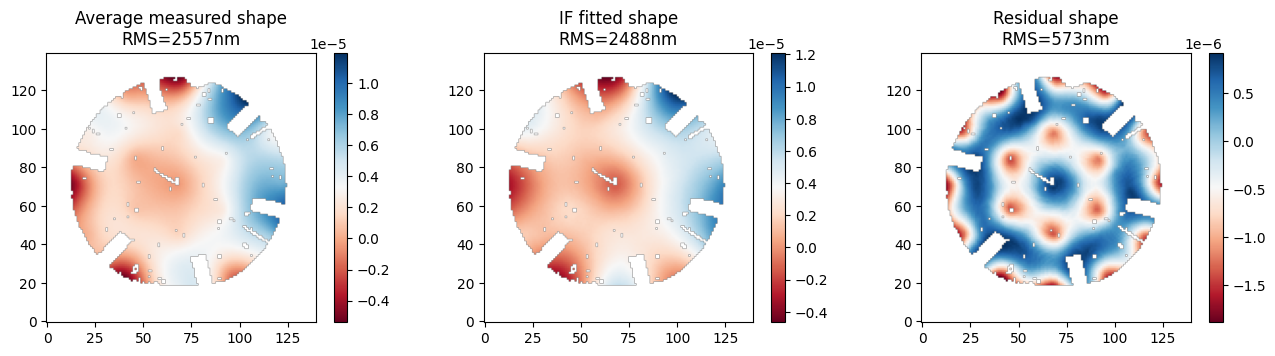

In [14]:

avg_img_rebin = rebin(pad_avg_img_2d,binned_shape)

coeffs = R @ avg_img_rebin[~mask_rebin]
fit_img = IF @ coeffs

fit_img_2d = reshape_on_mask(fit_img,mask_rebin)
diff = avg_img_rebin-fit_img_2d
diff -= np.mean(diff)

plt.figure(figsize=(16,3.5))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(avg_img_rebin,mask=mask_rebin),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'Average measured shape\nRMS={np.std(avg_img_rebin[~mask_rebin])*1e+9:1.0f}nm')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(fit_img_2d,mask=mask_rebin),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'IF fitted shape\nRMS={np.std(fit_img_2d[~mask_rebin])*1e+9:1.0f}nm')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(diff,mask=mask_rebin),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'Residual shape\nRMS={np.std(diff[~mask_rebin])*1e+9:1.0f}nm')

In [15]:
from scipy.ndimage import rotate, map_coordinates
from scipy.optimize import minimize

def fit_image_to_data(image, data, mask):
    # Find the size of the target data (defined on mask)
    # Assuming get_photocenter and rebin are defined elsewhere
    cx, cy = get_photocenter(1-mask)
    nx, ny = mask.shape
    
    # Correcting the mgrid axes to cleanly match the (nx, ny) shape
    Y, X = np.mgrid[0:nx, 0:ny] 
    X = X - cx
    Y = Y - cy
    rho = np.sqrt(X**2+Y**2)
    mask_radius = np.max(rho[~mask])

    # Rebin the input image to size
    target_shape = (int(np.ceil(2*mask_radius)), int(np.ceil(2*mask_radius)))
    image_rebin = rebin(image, target_shape)
    
    # Calculate the center of the newly rebinned square image
    cy_rebin, cx_rebin = target_shape[0] / 2.0, target_shape[1] / 2.0

    def objective(phi_array):
        """
        Objective function: Rotates the image, maps it to the mask grid, 
        scales its intensity, and returns the Sum of Squared Errors.
        """
        phi_val = phi_array[0]
        
        # 1. Rotate the rebinned image
        img_rot = rotate(image_rebin, phi_val, reshape=False, order=1, mode='nearest')
        
        # 2. Map the rotated image onto the target grid shape
        coords = np.array([Y + cy_rebin, X + cx_rebin])
        mapped_img = map_coordinates(img_rot, coords, order=1, mode='constant', cval=0.0)
        
        # 3. Extract only the valid regions defined by ~mask
        v_data = data[~mask]
        v_map = mapped_img[~mask]
        
        # 4. Calculate optimal intensity scale factor via linear regression
        scale = np.sum(v_data * v_map) / np.sum(v_map**2 + 1e-16)
        
        # 5. Return Sum of Squared Errors (SSE)
        return np.sum((v_data - scale * v_map)**2)

    # Find the rotation of the image_rebin which minimizes the difference
    # Due to the high symmetry of the pattern, we perform a coarse grid 
    # search first to avoid falling into an incorrect local minimum.
    best_err = np.inf
    best_phi = 0
    
    for angle in np.linspace(30, 90, 60): # 1-degree increments
        err = objective([angle])
        if err < best_err:
            best_err = err
            best_phi = angle

    # Polish the best initial guess with a local optimizer
    res = minimize(objective, [best_phi], method='Nelder-Mead')
    phi = res.x[0]

    # Rotate the image by the given amount and reshape it on the mask
    img_rot_best = rotate(image_rebin, phi, reshape=False, order=1, mode='nearest')
    
    # Map the final image onto the target mask grid
    coords_best = np.array([Y + cy_rebin, X + cx_rebin])
    image_best_fit = map_coordinates(img_rot_best, coords_best, order=1, mode='constant', cval=0.0)
    
    # Return as a numpy masked array
    return np.ma.masked_array(image_best_fit, mask=mask)

[0.80510434]


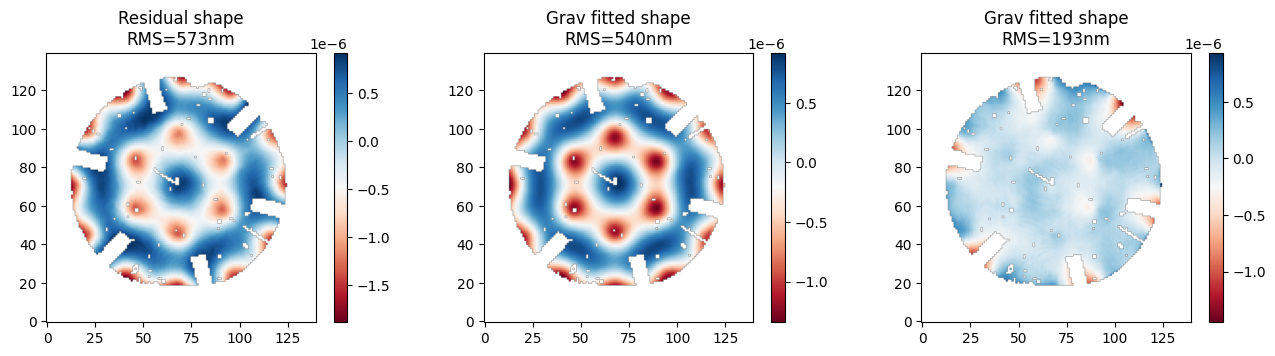

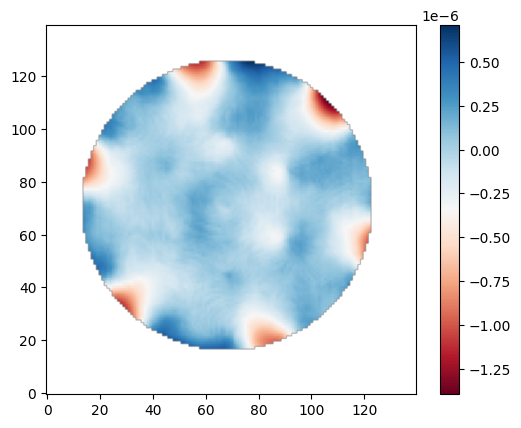

In [16]:
rebin_grav = rebin(grav,binned_shape)

fit_grav = fit_image_to_data(rebin_grav, diff, mask_rebin)
fit_grav = remove_ifs(fit_grav.data, IF, mask_rebin)

Rgrav = np.linalg.pinv((fit_grav[~mask_rebin]).reshape(-1,1))
scale = Rgrav @ diff[~mask_rebin]
fit_grav *= scale
print(scale)

res_fit = fit_grav-diff
res_fit = remove_ifs(res_fit, IF, mask_rebin)

z_valid = res_fit[valid_mask]
rbf = Rbf(x_valid, y_valid, z_valid, function='thin_plate', smooth=0)
Y, X = np.mgrid[0:img_rebin.shape[0], 0:img_rebin.shape[1]]
grav_fit_fill = rbf(X, Y)

plt.figure(figsize=(16,3.5))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(diff,mask=mask_rebin),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'Residual shape\nRMS={np.std(diff[~mask_rebin])*1e+9:1.0f}nm')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(fit_grav,mask=mask_rebin),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'Grav fitted shape\nRMS={np.std(fit_grav[~mask_rebin])*1e+9:1.0f}nm')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(grav_fit_fill,mask=mask_rebin),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'Grav fitted shape\nRMS={np.std(grav_fit_fill[~mask_rebin])*1e+9:1.0f}nm')

plt.figure()
plt.imshow(np.ma.masked_array(grav_fit_fill,mask=mask_fill),origin='lower',cmap='RdBu')
plt.colorbar()

In [17]:
c = 512/min(binned_shape)
pix_scale = 400e-3/450*c # m/pix


# def simulate_ibf(img, fwhm:float, mask=mask_rebin, amp:float=1e-8, pix_scale:float=pix_scale):

#     # Gaussian removal function
#     sigma = fwhm/pix_scale/(np.sqrt(np.log(2**8)))

#     X,Y = np.mgrid[0:img.shape[0],0:img.shape[1]]
#     X -= (np.max(X)-np.min(X))//2
#     Y -= (np.max(Y)-np.min(Y))//2
#     rf = 1/(2*np.pi*sigma**2)*np.exp(-(X**2+Y**2)/(2*sigma**2))
#     rf *= amp

#     # plt.figure()
#     # plt.imshow(rf,origin='lower',cmap='Blues')
#     # plt.colorbar()
#     # plt.title('Gaussian removal function')
#     if_coeffs = R @ img[~mask]
#     rec_img = reshape_on_mask(IF @ if_coeffs,mask)
#     img = img - rec_img

#     # Deconvolution
#     img_ft = np.fft.fft2(img)
#     rf_ft = np.fft.fft2(rf)

#     noise_power = amp  # adjust based on noise level
#     denominator = np.abs(rf_ft)**2 + noise_power
#     deconv_ft = img_ft * np.conj(rf_ft) / denominator
#     deconv = np.fft.ifft2(deconv_ft)
#     removed = np.fft.fftshift(deconv.real)

#     ibf_img = img-removed
#     if_coeffs = R @ ibf_img[~mask]
#     rec_ibf = reshape_on_mask(IF @ if_coeffs,mask)
#     ibf_fit = ibf_img - rec_ibf

#     plt.figure(figsize=(15,9))
#     plt.subplot(2,3,1)
#     plt.imshow(np.ma.masked_array(img,mask=mask), origin='lower', cmap='RdBu')
#     plt.colorbar(shrink=0.9)
#     plt.title(f'Before IBF\nRMS={np.std(img[~mask])*1e+9:1.0f}nm')
#     plt.subplot(2,3,2)
#     plt.imshow(np.ma.masked_array(removed,mask=mask), origin='lower', cmap='RdBu')
#     plt.colorbar(shrink=0.9)
#     plt.title(f'Removed material\nRMS={np.std(removed[~mask])*1e+9:1.0f}nm')
#     plt.subplot(2,3,3)
#     plt.imshow(np.ma.masked_array(ibf_img,mask=mask), origin='lower', cmap='RdBu')
#     plt.colorbar(shrink=0.9)
#     plt.title(f'After IBF\nRMS={np.std(ibf_img[~mask])*1e+9:1.0f}nm')
#     plt.subplot(2,3,4)
#     plt.imshow(np.ma.masked_array(rec_ibf,mask=mask), origin='lower', cmap='RdBu')
#     plt.colorbar(shrink=0.9)
#     plt.title(f'IF fitting\nRMS={np.std(rec_ibf[~mask])*1e+9:1.0f}nm')
#     plt.subplot(2,3,5)
#     plt.imshow(np.ma.masked_array(ibf_fit,mask=mask), origin='lower', cmap='RdBu')
#     plt.colorbar(shrink=0.9)
#     plt.title(f'After IBF and IF fitting\nRMS={np.std(ibf_fit[~mask])*1e+9:1.0f}nm')
#     return ibf_img

In [18]:
def simulate_ibf(img, fwhm:float, mask, show_mask = None,
                 amp: float = 1e-6, time_res:float=0.2,  pix_scale: float = pix_scale, snr: float = 50.0):
    """
    Simulates one step of Ion Beam Figuring.
    
    Args:
        img: 2D numpy array representing the target removal map (depth).
        fwhm: Full Width at Half Maximum of the Gaussian beam.
        amp: Peak volumetric removal rate of the beam.
        pix_scale: Physical size of a pixel.
        snr: Signal-to-Noise ratio for the Wiener filter regularization.
        
    Returns:
        ibf_img: The residual map (img - actual_removed).
        dwell_time: The calculated dwell time map.
        actual_removed: The actual topography removed in this step.
    """

    if show_mask is None:
        show_mask = mask.copy()
    
    # 1. Gaussian removal function
    # Standard formula: FWHM = 2 * sqrt(2 * ln(2)) * sigma
    sigma = (fwhm / pix_scale) / (2 * np.sqrt(2 * np.log(2)))

    ny, nx = img.shape
    Y, X = np.mgrid[0:ny, 0:nx]
    
    # Center the grid coordinates
    X = X - nx // 2
    Y = Y - ny // 2
    
    # Calculate Removal Function (rf)
    rf = (1 / (2 * np.pi * sigma**2)) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    rf *= amp

    # 2. Shift the kernel to the origin before FFT to prevent phase shifts
    rf_shifted = np.fft.ifftshift(rf)

    # 3. Frequency domain transformations
    img_ft = np.fft.fft2(img)
    rf_ft = np.fft.fft2(rf_shifted)

    # 4. Wiener Deconvolution (Calculate Dwell Time)
    # Define regularization parameter based on max power and desired SNR
    reg_param = np.max(np.abs(rf_ft)**2) / snr
    denominator = np.abs(rf_ft)**2 + reg_param
    
    dwell_ft = img_ft * np.conj(rf_ft) / denominator
    dwell_time = np.fft.ifft2(dwell_ft).real

    # 5. Enforce physical constraints: Time cannot be negative
    # dwell_time[dwell_time < 0] = 0
    dwell_time -= np.min(dwell_time)
    dwell_time = np.round(dwell_time/time_res)*time_res

    # 6. Calculate Actual Removal (Convolve Dwell Time with Removal Function)
    # Convolution in Fourier space: F(dwell) * F(rf)
    actual_removed_ft = np.fft.fft2(dwell_time) * rf_ft
    actual_removed = np.fft.ifft2(actual_removed_ft).real

    # 7. Calculate residual map
    ibf_img = img - actual_removed
    ibf_img -= np.mean(ibf_img)

    sh = 0.7
    plt.figure(figsize=(18,4.4))
    plt.subplot(1,4,1)
    plt.imshow(np.ma.masked_array(img,mask=show_mask), origin='lower', cmap='RdBu')
    plt.colorbar(shrink=sh)
    plt.title(f'Before IBF\nRMS={np.std(img[~show_mask])*1e+9:1.0f}nm')
    plt.subplot(1,4,3)
    plt.imshow(np.ma.masked_array(actual_removed,mask=show_mask), origin='lower', cmap='RdBu')
    plt.colorbar(shrink=sh)
    plt.title(f'Removed material\nRMS={np.std(actual_removed[~show_mask])*1e+9:1.0f}nm')
    plt.subplot(1,4,2)
    plt.imshow(np.ma.masked_array(dwell_time,mask=show_mask), origin='lower', cmap='RdBu')
    plt.colorbar(shrink=sh)
    plt.title(f'Dwell time\nTotal = {np.sum(dwell_time)/3600:1.1f} hours')
    plt.subplot(1,4,4)
    plt.imshow(np.ma.masked_array(ibf_img,mask=show_mask), origin='lower', cmap='RdBu')
    plt.colorbar(shrink=sh)
    plt.title(f'Residual\nRMS={np.std(ibf_img[~show_mask])*1e+9:1.0f}nm')

    return ibf_img#, dwell_time, actual_removed

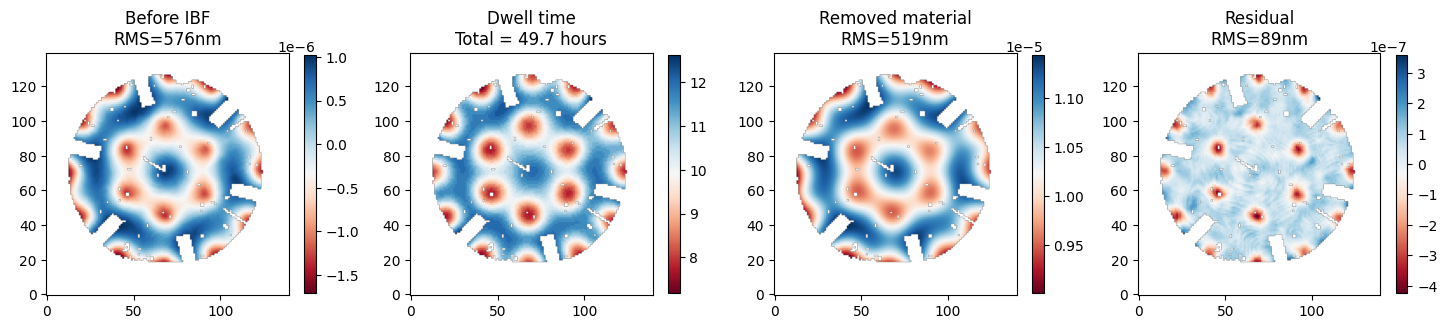

In [19]:
ibf50_img = simulate_ibf(diff_fill, fwhm=50e-3, mask=mask_rebin)
# ibf5_img = simulate_ibf(diff_fill, fwhm=5e-3)

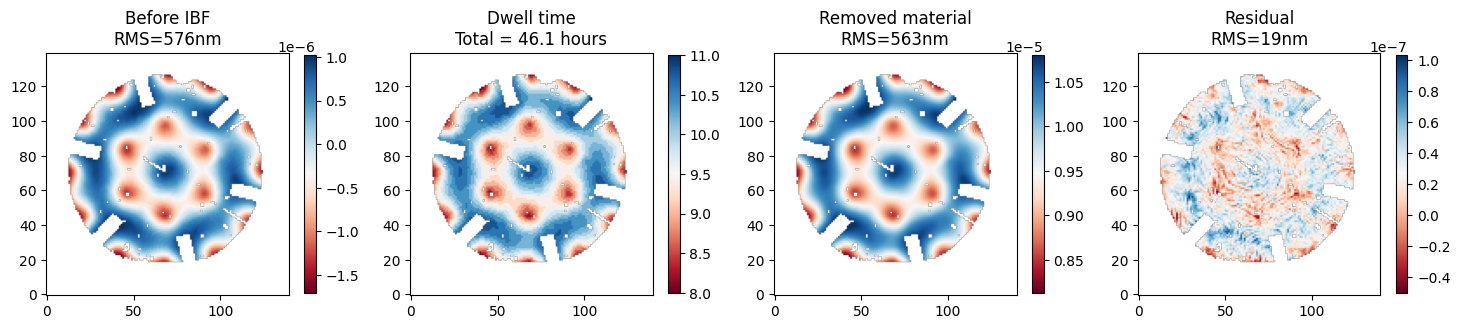

In [20]:
ibf13_img = simulate_ibf(diff_fill, fwhm=13e-3, mask=mask_rebin)

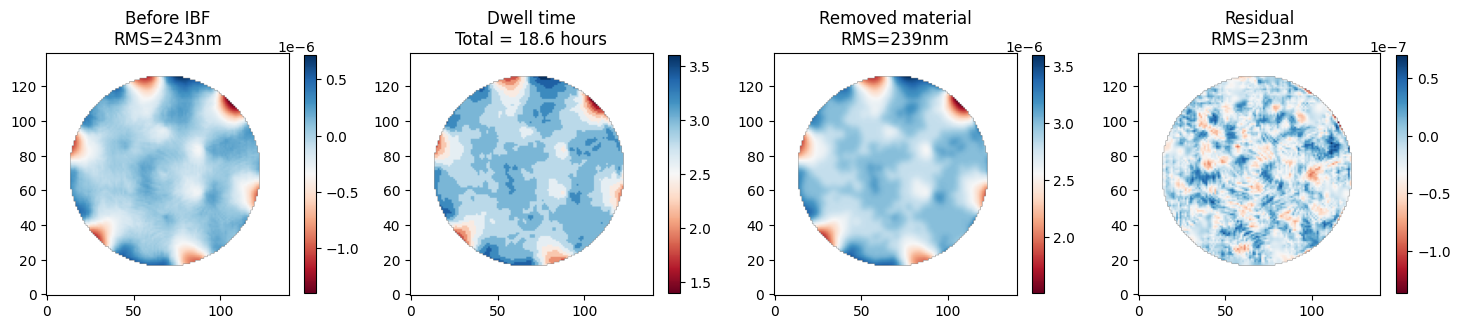

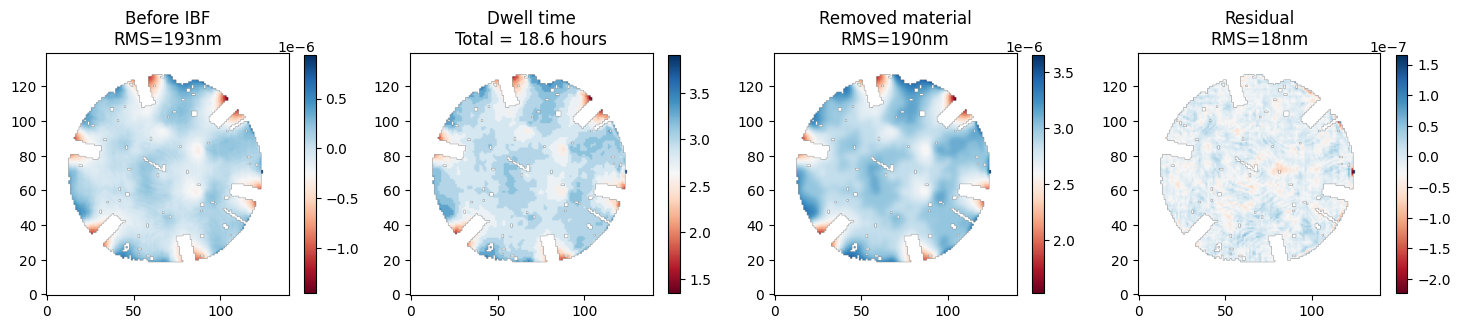

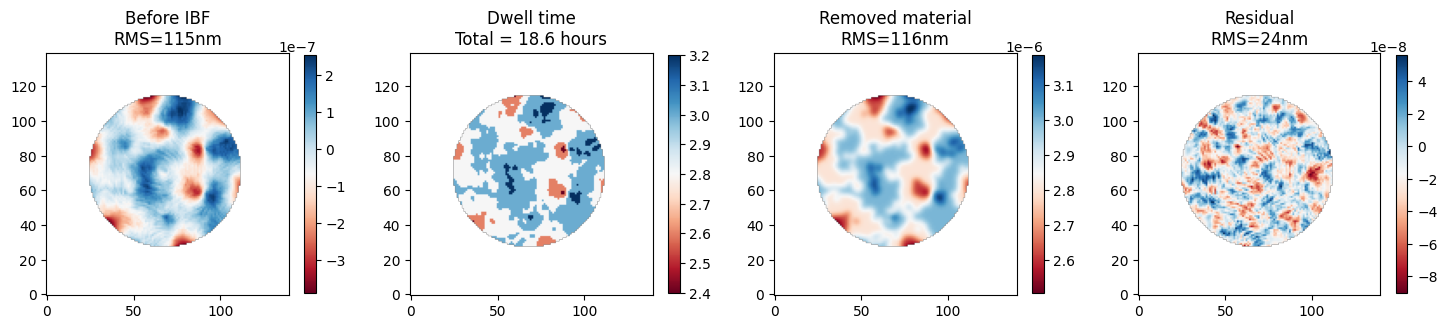

In [21]:
ibf13_img = simulate_ibf(grav_fit_fill, fwhm=13e-3, mask=mask_fill)
ibf13_img = simulate_ibf(grav_fit_fill, fwhm=13e-3, mask=mask_fill, show_mask=mask_rebin, snr=50, time_res=0.15)
ibf13_img = simulate_ibf(grav_fit_fill, fwhm=13e-3, mask=mask_inner)

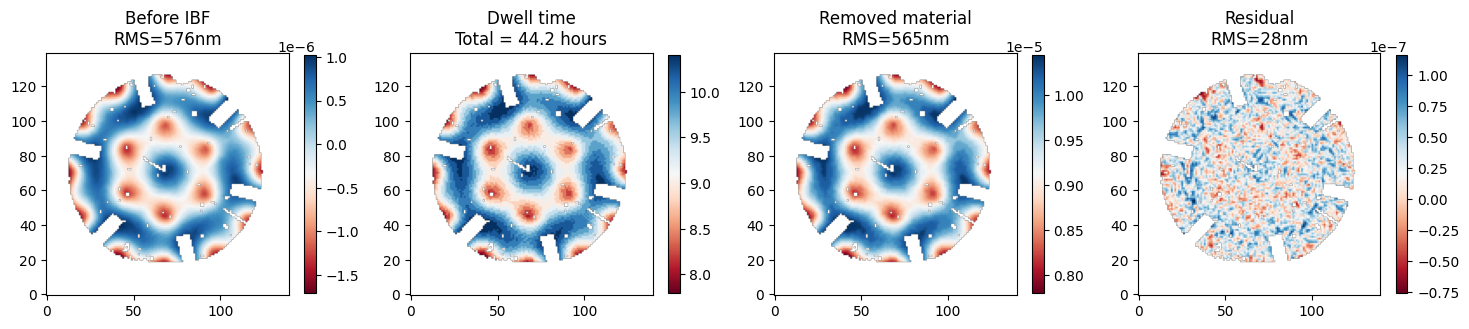

In [22]:
ibf5_img = simulate_ibf(diff_fill, fwhm=5e-3, mask=mask_rebin)

In [23]:
import scipy
import scipy.stats as stats
def comp_psd(timg, mask, verbose=False, normalize=True):

    # reshape and pad

    sz = max(timg.shape)
    npix = sz**2
    
    img = timg * mask
    tf2d = scipy.fft.ifft2(img,norm='ortho') #fft2(img,norm='ortho')
    
    if np.abs(np.mean(img[mask==1])) > 1e-9:
        print("Warning: piston not removed %g" % np.abs(np.mean(img[mask==1])))
        verbose=1
    orig_tf2d = np.abs(tf2d[0,0])
    tf2d_power_spectrum = np.abs(tf2d)**2

    kfreq = np.fft.fftfreq(sz)                 #freq spaziale in 1/pixel
    kfreq2D = np.meshgrid(kfreq, kfreq)            #griglia di frequenze xx e yy
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)  #griglia di frequenze distanza

    knrm = knrm.flatten()
    fourier_amplitudes = tf2d_power_spectrum.flatten()
    kbins = kfreq[0:sz//2+1]
    kbins[-1] = max(kbins)+kbins[1]
    
    Abins, _, _  = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "sum",
                                         bins = kbins)
    ediff = (np.sum(img[mask==1]**2) - np.sum(Abins))/np.sum(img[mask==1]**2)

    #normalize energy
    rmsima = np.sqrt(np.sum(img**2)/npix)
    rmsbs = np.sqrt(np.sum(Abins*(kfreq[1]**2)))
    rmspsd = np.sqrt(np.sum(tf2d_power_spectrum*(kfreq[1]**2)))
    rmsmasked = np.sqrt(np.sum(img[mask==1]**2/np.sum(mask)))
    Abins_normalized = Abins * (rmsmasked/rmsbs)**2
    if normalize:
        Abins = Abins_normalized
        if verbose:
            print("Normalization applied")
        
    rmsbsnorm = np.sqrt(np.sum(Abins_normalized*(kfreq[1]**2)))

    if verbose:
        print("Energy difference before normalization %e" % ediff)
        print("Freq 0: %g" % orig_tf2d)
        print("RMS image masked [m] %g" % rmsmasked)
        print("RMS image [m] %g" % rmsima)
        print("RMS from PSD-BS [m] %g" % rmsbs)
        print("RMS from PSD-2D [m] %g" % rmspsd)
        print("RMS from PSD-BS normalized [m] %g" % rmsbsnorm)

    ediff = (np.sum(img[mask==1]**2) - np.sum(Abins))/np.sum(img[mask==1]**2)
    print("Energy difference after normalization %e" % ediff)
    return (kfreq[0:sz//2], Abins)

In [24]:
from arte.utils.radial_profile import computeRadialProfile

def get_img_rad_profile(img,mask,oversampling:int=12):
    pad_width = int(max(img.shape)*(oversampling-1)/2)
    pad_img = np.pad(img,pad_width=pad_width,mode='constant',constant_values=0.0)
    img_ft = np.fft.fftshift(np.fft.fft2(pad_img))
    psd = np.abs(img_ft)**2
    # phase_var = np.std(img[~mask])**2 
    # psd *= phase_var / np.sum(psd)
    psd /= (pad_img.shape[0] * pad_img.shape[1])
    phase_var = np.var(img[~mask])
    psd *= phase_var / np.nanmean(psd)
    cx,cy = get_photocenter(1-mask)
    rad_psd, dist = computeRadialProfile(psd, cy*oversampling, cx*oversampling)
    return rad_psd, dist#*pix_scale

In [25]:
avg_img_rebin = rebin(avg_img_2d, binned_shape)

kpix, psd_img = comp_psd(avg_img_rebin-np.mean(avg_img_rebin[~mask_rebin]), 1-mask_rebin, normalize=False)
kpix, psd_diff = comp_psd(diff_fill-np.mean(diff_fill[~mask_rebin]), 1-mask_rebin, normalize=False)
kpix, psd_ibf50 = comp_psd(ibf50_img-np.mean(ibf50_img[~mask_rebin]), 1-mask_rebin, normalize=False)
kpix, psd_ibf13 = comp_psd(ibf13_img-np.mean(ibf13_img[~mask_rebin]), 1-mask_rebin, normalize=False)
kpix, psd_ibf5 = comp_psd(ibf5_img-np.mean(ibf5_img[~mask_rebin]), 1-mask_rebin, normalize=False)

Energy difference after normalization 6.896592e-03
Energy difference after normalization 7.197967e-03
Energy difference after normalization 1.025099e-02
Energy difference after normalization 2.537147e-02
Energy difference after normalization 2.614896e-02


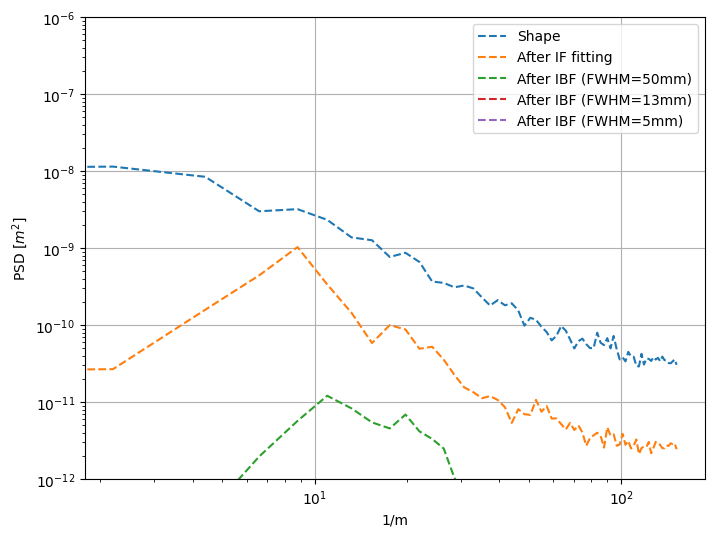

In [26]:
plt.figure(figsize=(8,6))
plt.plot(kpix/pix_scale,psd_img,'--',label='Shape')
plt.plot(kpix/pix_scale,psd_diff,'--',label='After IF fitting')
plt.plot(kpix/pix_scale,psd_ibf50,'--',label='After IBF (FWHM=50mm)')
plt.plot(kpix/pix_scale,psd_ibf13,'--',label='After IBF (FWHM=13mm)')
plt.plot(kpix/pix_scale,psd_ibf5,'--',label='After IBF (FWHM=5mm)')
plt.legend()
plt.ylim([1e-12,1e-6])
plt.xlabel('1/m')
plt.ylabel(r'PSD [$m^2$]')
plt.xscale('log')
plt.yscale('log')
plt.grid()

In [27]:
# psd_img, dpix = get_img_rad_profile(avg_img_2d, master_mask)
# psd_diff, dpix = get_img_rad_profile(diff, master_mask)
# psd_ibf13, dpix = get_img_rad_profile(ibf13_img, master_mask)
# psd_ibf10, dpix = get_img_rad_profile(ibf10_img, master_mask)
# psd_ibf6, dpix = get_img_rad_profile(ibf6_img, master_mask)
# psd_ibf2, dpix = get_img_rad_profile(ibf2_img, master_mask)

In [28]:
# plt.figure(figsize=(8,6))
# plt.plot(dpix,psd_img,'--',label='Shape')
# plt.plot(dpix,psd_diff,'--',label='After IF fitting')
# plt.plot(dpix,psd_ibf13,'--',label='After IBF (FWHM=13mm)')
# plt.plot(dpix,psd_ibf10,'--',label='After IBF (FWHM=10mm)')
# plt.plot(dpix,psd_ibf6,'--',label='After IBF (FWHM=6mm)')
# # plt.plot(dpix,psd_ibf2,'--',label='After IBF (FWHM=2mm)')
# plt.legend()
# # plt.xlim([0.1,20])
# # plt.xlabel('1/m')
# plt.ylabel(r'PSD [$m^2$]')
# plt.xscale('log')
# plt.yscale('log')
# plt.grid()